In [4]:
%pip install ucimlrepo


  Using cached ucimlrepo-0.0.7-py3-none-any.whl.metadata (5.5 kB)
Using cached ucimlrepo-0.0.7-py3-none-any.whl (8.0 kB)
Note: you may need to restart the kernel to use updated packages.


In [5]:
from ucimlrepo import fetch_ucirepo
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix




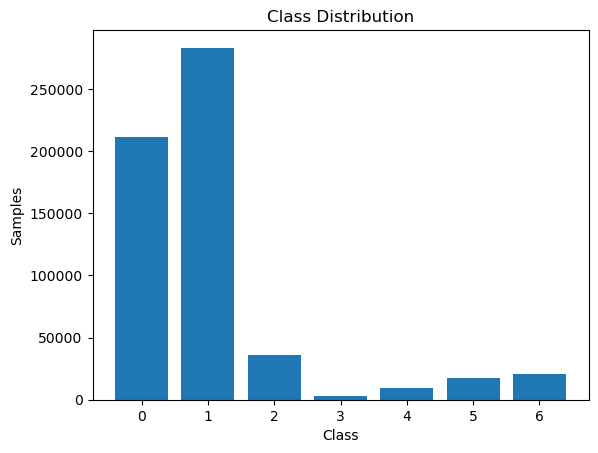

In [7]:
data = fetch_ucirepo(id=31)
X = data.data.features.values
y = data.data.targets.values.ravel() - 1
counts = np.bincount(y)
plt.bar(range(7), counts)
plt.xlabel("Class")
plt.ylabel("Samples")
plt.title("Class Distribution")
plt.show()

In [8]:
Y = np.eye(7)[y]
X_train, X_temp, Y_train, Y_temp, y_train, y_temp = train_test_split(
    X, Y, y, test_size=0.2, random_state=42, stratify=y
)
X_val, X_test, Y_val, Y_test, y_val, y_test = train_test_split(
    X_temp, Y_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp
)


In [9]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)
N = len(y_train)
class_weights = N / (7 * np.bincount(y_train, minlength=7))
np.random.seed(42)

W1 = np.random.randn(54, 64) * np.sqrt(2 / 54)
b1 = np.zeros((1, 64))

W2 = np.random.randn(64, 32) * np.sqrt(2 / 64)
b2 = np.zeros((1, 32))

W3 = np.random.randn(32, 16) * np.sqrt(2 / 32)
b3 = np.zeros((1, 16))

W4 = np.random.randn(16, 7) * np.sqrt(2 / 16)
b4 = np.zeros((1, 7))

lr = 0.01
batch_size = 128


In [10]:
def relu(x):
    return np.maximum(0, x)


def softmax(x):
    x = x - np.max(x, axis=1, keepdims=True)
    e = np.exp(x)
    return e / np.sum(e, axis=1, keepdims=True)


def forward(X):
    z1 = X @ W1 + b1
    a1 = relu(z1)

    z2 = a1 @ W2 + b2
    a2 = relu(z2)

    z3 = a2 @ W3 + b3
    a3 = relu(z3)

    z4 = a3 @ W4 + b4
    y_hat = softmax(z4)

    return y_hat, (z1, a1, z2, a2, z3, a3)


def loss(y, y_hat):
    y_hat = np.clip(y_hat, 1e-12, 1)
    weights = class_weights[np.argmax(y, axis=1)]

    return -np.mean(
        weights * np.sum(y * np.log(y_hat), axis=1)
    )

In [11]:
train_loss = []
val_loss = []
train_acc = []
val_acc = []

best_loss = np.inf
wait = 0
patience = 15

for epoch in range(50):

    idx = np.random.permutation(len(X_train))
    Xs = X_train[idx]
    Ys = Y_train[idx]

    for i in range(0, len(Xs), batch_size):

        xb = Xs[i:i + batch_size]
        yb = Ys[i:i + batch_size]

        yh, cache = forward(xb)
        z1, a1, z2, a2, z3, a3 = cache

        m = len(xb)
        weights = class_weights[np.argmax(yb, axis=1)]

        dz4 = (yh - yb) * weights[:, None] / m
        dW4 = a3.T @ dz4
        db4 = np.sum(dz4, axis=0, keepdims=True)

        dz3 = (dz4 @ W4.T) * (z3 > 0)
        dW3 = a2.T @ dz3
        db3 = np.sum(dz3, axis=0, keepdims=True)

        dz2 = (dz3 @ W3.T) * (z2 > 0)
        dW2 = a1.T @ dz2
        db2 = np.sum(dz2, axis=0, keepdims=True)

        dz1 = (dz2 @ W2.T) * (z1 > 0)
        dW1 = xb.T @ dz1
        db1 = np.sum(dz1, axis=0, keepdims=True)

        W1 -= lr * dW1
        b1 -= lr * db1
        W2 -= lr * dW2
        b2 -= lr * db2
        W3 -= lr * dW3
        b3 -= lr * db3
        W4 -= lr * dW4
        b4 -= lr * db4

    # Metrics
    p_train, _ = forward(X_train)
    p_val, _ = forward(X_val)

    tl = loss(Y_train, p_train)
    vl = loss(Y_val, p_val)

    tr = np.argmax(p_train, axis=1)
    va = np.argmax(p_val, axis=1)

    ta = accuracy_score(y_train, tr)
    va_acc = accuracy_score(y_val, va)

    train_loss.append(tl)
    val_loss.append(vl)
    train_acc.append(ta)
    val_acc.append(va_acc)

    print(
        f"Epoch {epoch+1:02d} | "
        f"Train Loss: {tl:.4f} | Val Loss: {vl:.4f} | "
        f"Train Acc: {ta:.4f} | Val Acc: {va_acc:.4f}"
    )

    if vl < best_loss:
        best_loss = vl
        wait = 0

        best = [
            W1.copy(), b1.copy(),
            W2.copy(), b2.copy(),
            W3.copy(), b3.copy(),
            W4.copy(), b4.copy()
        ]
    else:
        wait += 1
        if wait == patience:
            print("Early stopping")
            break


Epoch 01 | Train Loss: 0.6900 | Val Loss: 0.7041 | Train Acc: 0.5896 | Val Acc: 0.5897
Epoch 02 | Train Loss: 0.6319 | Val Loss: 0.6388 | Train Acc: 0.6174 | Val Acc: 0.6167
Epoch 03 | Train Loss: 0.5771 | Val Loss: 0.5888 | Train Acc: 0.6476 | Val Acc: 0.6473
Epoch 04 | Train Loss: 0.5602 | Val Loss: 0.5766 | Train Acc: 0.6840 | Val Acc: 0.6859
Epoch 05 | Train Loss: 0.5388 | Val Loss: 0.5516 | Train Acc: 0.6751 | Val Acc: 0.6759
Epoch 06 | Train Loss: 0.5109 | Val Loss: 0.5191 | Train Acc: 0.6814 | Val Acc: 0.6834
Epoch 07 | Train Loss: 0.5210 | Val Loss: 0.5357 | Train Acc: 0.7005 | Val Acc: 0.7023
Epoch 08 | Train Loss: 0.4897 | Val Loss: 0.4995 | Train Acc: 0.6698 | Val Acc: 0.6701
Epoch 09 | Train Loss: 0.4800 | Val Loss: 0.4872 | Train Acc: 0.7132 | Val Acc: 0.7148
Epoch 10 | Train Loss: 0.4697 | Val Loss: 0.4797 | Train Acc: 0.7105 | Val Acc: 0.7125
Epoch 11 | Train Loss: 0.4549 | Val Loss: 0.4629 | Train Acc: 0.7086 | Val Acc: 0.7101
Epoch 12 | Train Loss: 0.4971 | Val Loss: 0

In [12]:
W1, b1, W2, b2, W3, b3, W4, b4 = best
test_prob, _ = forward(X_test)
test_pred = np.argmax(test_prob, axis=1)

print("\nAccuracy:", accuracy_score(y_test, test_pred))
print("Macro Precision:", precision_score(y_test, test_pred, average="macro", zero_division=0))
print("Macro Recall:", recall_score(y_test, test_pred, average="macro", zero_division=0))
print("Macro F1:", f1_score(y_test, test_pred, average="macro", zero_division=0))


Accuracy: 0.7895253175450071
Macro Precision: 0.6783765460259202
Macro Recall: 0.8728384380296037
Macro F1: 0.7408937133832857


In [13]:
precision = precision_score(y_test, test_pred, average=None, zero_division=0)
recall = recall_score(y_test, test_pred, average=None, zero_division=0)
f1 = f1_score(y_test, test_pred, average=None, zero_division=0)

print("\nPer-class Precision:", precision)
print("Per-class Recall:", recall)
print("Per-class F1:", f1)


Per-class Precision: [0.79156362 0.86644118 0.78817346 0.58482143 0.31635112 0.59821065
 0.80307437]
Per-class Recall: [0.81585159 0.7414493  0.83864653 0.95620438 0.96838778 0.84686241
 0.94246709]
Per-class F1: [0.80352411 0.79908702 0.81262702 0.72576177 0.47690711 0.70114395
 0.86720502]


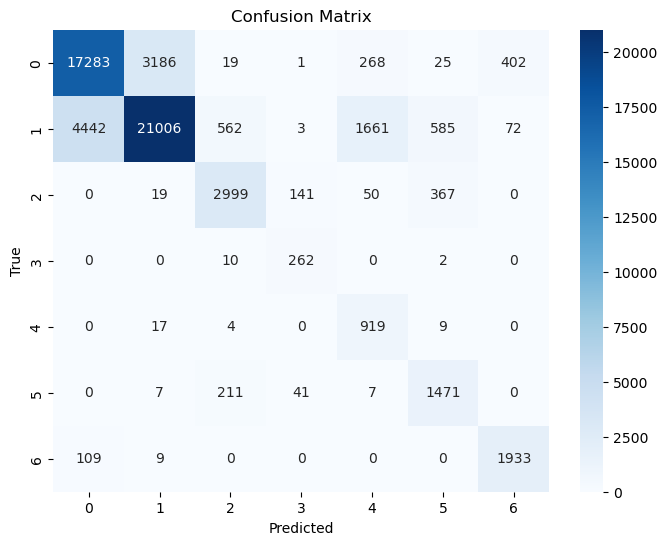

In [14]:
cm = confusion_matrix(y_test, test_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()



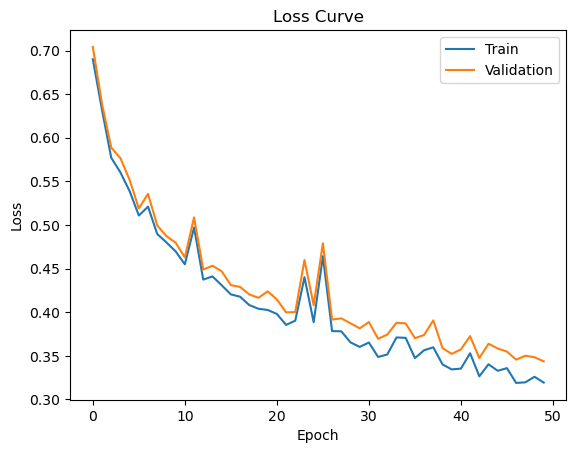

In [15]:
plt.plot(train_loss, label="Train")
plt.plot(val_loss, label="Validation")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Loss Curve")
plt.legend()
plt.show()

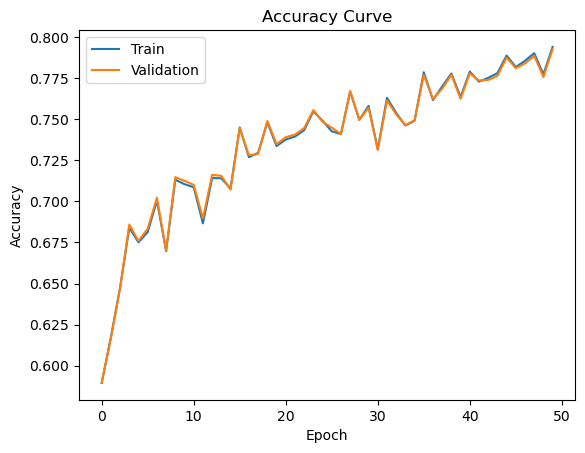

In [16]:
plt.plot(train_acc, label="Train")
plt.plot(val_acc, label="Validation")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Accuracy Curve")
plt.legend()
plt.show()

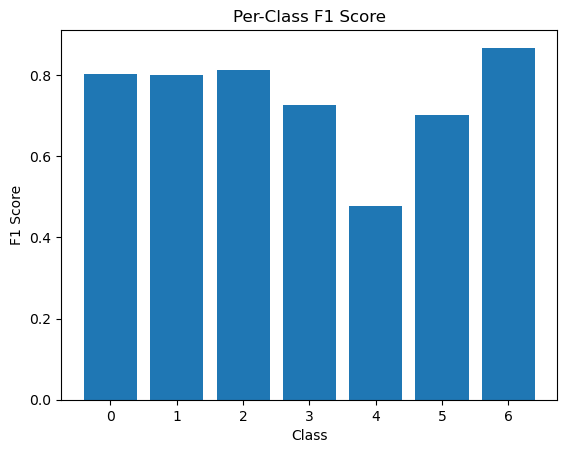

In [17]:
plt.bar(range(7), f1)
plt.xlabel("Class")
plt.ylabel("F1 Score")
plt.title("Per-Class F1 Score")
plt.show()

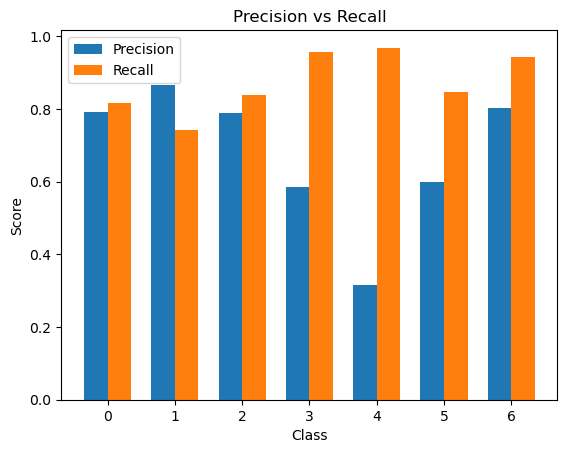

In [18]:
x = np.arange(7)
w = 0.35

plt.bar(x - w/2, precision, w, label="Precision")
plt.bar(x + w/2, recall, w, label="Recall")
plt.xlabel("Class")
plt.ylabel("Score")
plt.title("Precision vs Recall")
plt.legend()
plt.show()

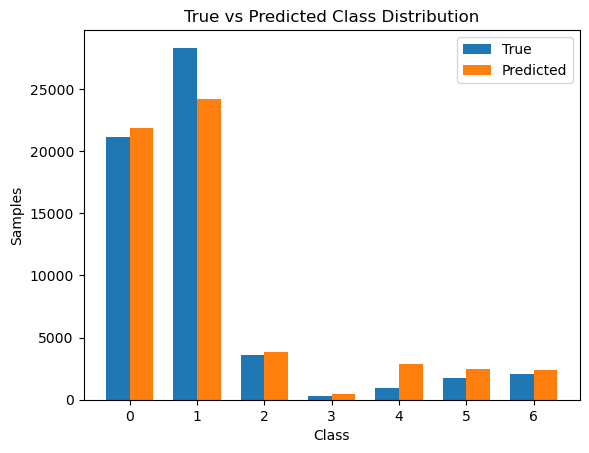

In [19]:
plt.bar(x - w/2, np.bincount(y_test, minlength=7), w, label="True")
plt.bar(x + w/2, np.bincount(test_pred, minlength=7), w, label="Predicted")
plt.xlabel("Class")
plt.ylabel("Samples")
plt.title("True vs Predicted Class Distribution")
plt.legend()
plt.show()